# SDHNet — Grayscale Training

Trains the grayscale version of SDHNet (ResNet18, `pretrained=False`, `n_in=1`) on the 4-class SDH dataset.

This is the model used in the RISE experiment — Kawai converted all stimuli to grayscale, so we match that here.

Run this notebook in parallel with `sdhnet_4class_color.ipynb` to halve wall time.

Dataset: `data/sdh_500_clean/` (background-removed, gray composite).

In [1]:
from fastai.vision.all import *
from torchvision.models import resnet18  # explicit import so linters resolve the name

# Auto-pick the largest available dataset. sdh_500 is the target; sdh_200
# is the previous build kept around for quick smoke tests while the
# download_more_images.py + prepare_dataset.py rebuild is in flight.
for candidate in ('data/sdh_500_clean', 'data/sdh_500', 'data/sdh_200'):
    if Path(candidate).exists():
        path = Path(candidate)
        break
else:
    raise FileNotFoundError('No SDH dataset found — run prepare_dataset.py first.')
print(f'Using dataset: {path}')
path.ls()

/Users/ossie/anaconda3/envs/fastbook/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using dataset: data/sdh_500_clean


(#2) [Path('data/sdh_500_clean/valid'),Path('data/sdh_500_clean/train')]

## Helper functions

### Choosing a learning rate: `valley` vs. `(min + steep) / 2`

fastai's `lr_find` runs a brief training loop where the learning rate is increased exponentially from tiny (~1e-7) to huge (~1). It records the loss at each step, then offers several heuristics for picking a good LR from the resulting curve.

The earlier prototype notebooks averaged two of these:

- **`lr_steep`** — the LR with the steepest negative gradient ("loss is falling fastest here")
- **`lr_min`** — the LR right before loss starts climbing again ("one step hotter and we diverge")

Averaging them lands halfway between *fastest progress* and *about to blow up* — which is too aggressive, especially for `fit_one_cycle`, which then multiplies that value by ~25× during the warmup phase. With pretrained weights the model is robust enough to survive that overshoot; from random weights it isn't, and we saw `valid_loss` spike to 8.5 in the first three epochs of the ResNet34 run.

**`valley`** is fastai's recommended default for scratch training. It smooths the loss curve, finds the longest contiguous stretch where loss is steadily decreasing, and picks an LR roughly in the middle of that descending segment. The intuition: instead of chasing the *fastest* descent (which sits near the cliff edge), it sits in the *most reliable* descent — well clear of divergence, with safety margin on both sides. For one-cycle training the resulting peak LR stays inside the stable zone even after the warmup multiplier.

In [2]:
def get_lr(learn):
    """Return fastai's `valley` LR suggestion. See the markdown above for why
    we use `valley` instead of the (min+steep)/2 average from earlier prototypes."""
    suggested = learn.lr_find(suggest_funcs=valley)
    lr = float(suggested.valley)
    print(f'Suggested LR (valley): {lr:.6g}')
    return lr

## Grayscale model

This is the version we'll use for the RISE experiment. Kawai converted all stimuli to grayscale before running RISE, keeping luminance and contrast constant across categories. We match that here.

One architectural note: ResNet's first conv layer expects 3-channel input. We handle this by converting images to grayscale via `PILImageBW` and then using `n_in=1` in `vision_learner`, which replaces the first conv layer to accept single-channel input.

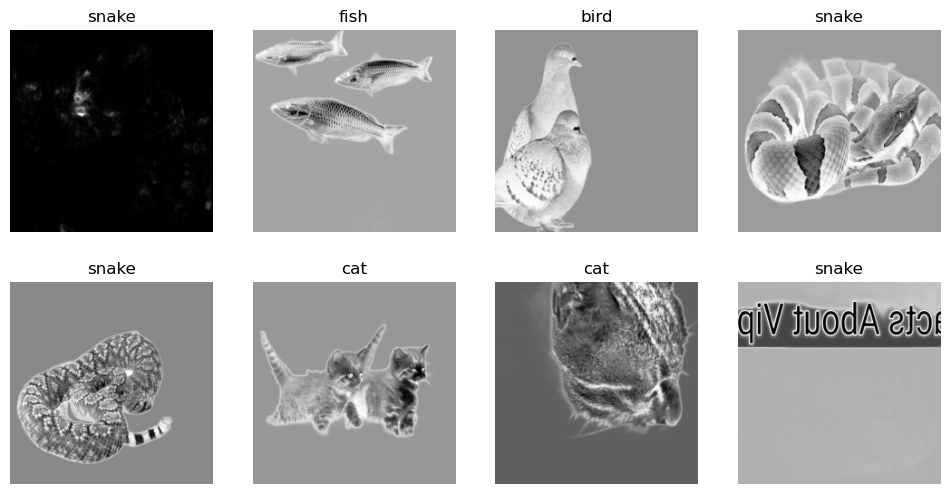

In [3]:
dblock_gray = DataBlock(
    blocks      = (ImageBlock(cls=PILImageBW), CategoryBlock),
    get_items   = get_image_files,
    get_y       = parent_label,
    splitter    = GrandparentSplitter(train_name='train', valid_name='valid'),
    item_tfms   = RandomResizedCrop(224, min_scale=0.75),
    batch_tfms  = [Flip(), Brightness(max_lighting=0.2),
                   Normalize.from_stats([0.449], [0.226])]  # grayscale imagenet stats
)

dls_gray = dblock_gray.dataloaders(path, batch_size=32)
dls_gray.show_batch(max_n=8, figsize=(12, 6))

In [4]:
learn_gray = vision_learner(
    dls_gray,
    resnet18,    # match the color model — smaller arch for scratch training on small data
    metrics=[accuracy, F1Score(average='macro')],
    pretrained=False,
    n_in=1  # single-channel input
)

Suggested LR (valley): 0.00144544


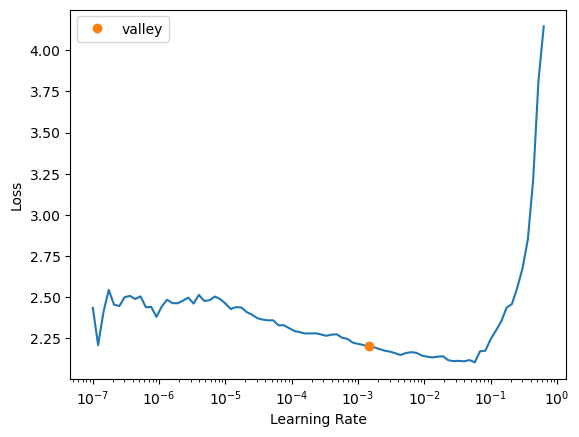

In [5]:
lr_gray = get_lr(learn_gray)

In [6]:
cbs = [EarlyStoppingCallback(monitor='valid_loss', min_delta=0.005, patience=8),
       SaveModelCallback(monitor='valid_loss', fname='sdhnet-4class-gray-best')]
learn_gray.fit_one_cycle(50, lr_gray, cbs=cbs)

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,1.868950,1.488490,0.425000,0.402564,00:32
1,1.808565,1.376052,0.482500,0.478470,00:31
2,1.730371,1.372169,0.467500,0.457364,00:29
3,1.658122,1.278752,0.500000,0.487967,00:29
4,1.559969,1.321859,0.495000,0.477944,00:29
5,1.483991,1.334195,0.537500,0.535486,00:29
6,1.438865,2.800083,0.365000,0.302532,00:29
7,1.334674,1.404304,0.530000,0.531454,00:28
8,1.259042,2.318455,0.387500,0.335482,00:28
9,1.243131,1.139570,0.565000,0.563577,00:30


Better model found at epoch 0 with valid_loss value: 1.4884904623031616.
Better model found at epoch 1 with valid_loss value: 1.376051902770996.
Better model found at epoch 2 with valid_loss value: 1.3721685409545898.
Better model found at epoch 3 with valid_loss value: 1.2787519693374634.
Better model found at epoch 9 with valid_loss value: 1.1395697593688965.
Better model found at epoch 14 with valid_loss value: 1.063050389289856.
Better model found at epoch 16 with valid_loss value: 0.9316619634628296.
Better model found at epoch 21 with valid_loss value: 0.8904688954353333.
Better model found at epoch 22 with valid_loss value: 0.8456902503967285.
Better model found at epoch 29 with valid_loss value: 0.827419638633728.
Better model found at epoch 30 with valid_loss value: 0.7495728135108948.
Better model found at epoch 31 with valid_loss value: 0.7448621988296509.
Better model found at epoch 34 with valid_loss value: 0.6711096167564392.
No improvement since epoch 34: early stopping


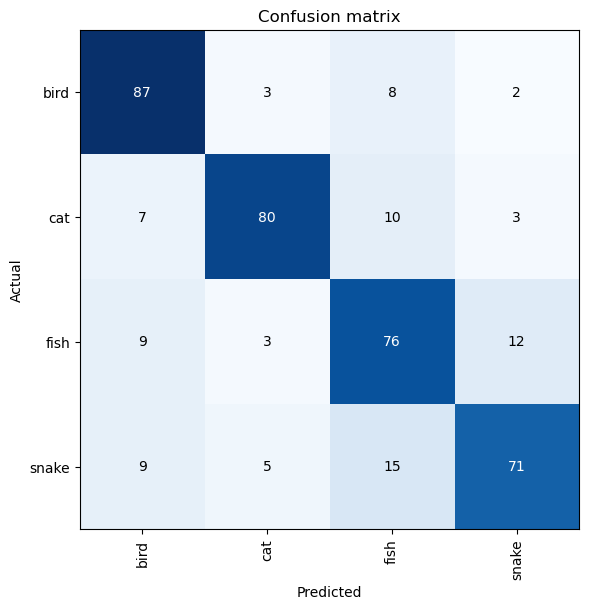

In [7]:
interp_gray = ClassificationInterpretation.from_learner(learn_gray)
interp_gray.plot_confusion_matrix(figsize=(6, 6))

In [11]:
interp_gray.print_classification_report()

              precision    recall  f1-score   support

        bird       0.78      0.87      0.82       100
         cat       0.88      0.80      0.84       100
        fish       0.70      0.76      0.73       100
       snake       0.81      0.71      0.76       100

    accuracy                           0.79       400
   macro avg       0.79      0.78      0.79       400
weighted avg       0.79      0.79      0.79       400



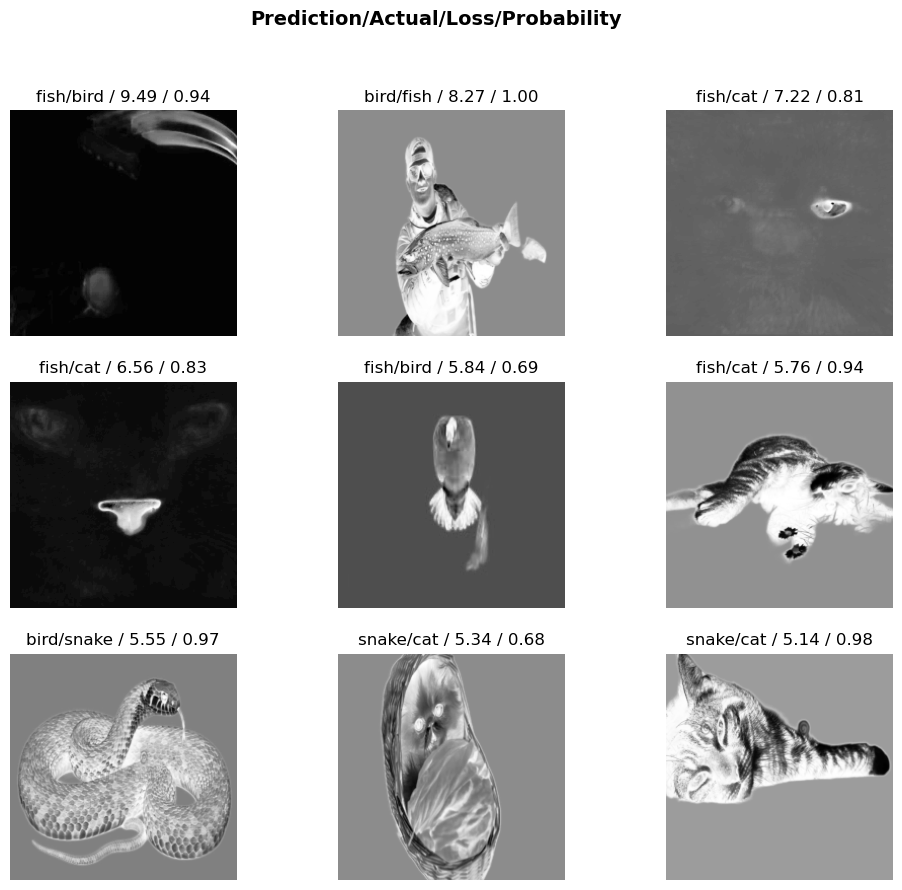

In [8]:
interp_gray.plot_top_losses(9, figsize=(12, 10))

In [9]:
learn_gray.save('sdhnet-4class-gray')
print('Grayscale model saved.')

Grayscale model saved.


## Next step: RISE

With the grayscale model trained, the next notebook (`rise_experiment.ipynb`) will:
1. Generate RISE sequences (20 steps, 95%→0% phase scrambling) for each validation image
2. Feed each step through `learn_gray` and record the step at which the model first predicts correctly
3. Compare mean detection thresholds across snake / bird / cat / fish
4. Repeat with Claude via API (4-AFC prompt)
5. Plot detection curves against Kawai's human results

In parallel, `sdhnet_4class_pretrained_compare.ipynb` will repeat color + grayscale training with `pretrained=True` so we can quantify how much of any snake advantage is inherited from ImageNet versus learned from this dataset.
